# Atividade 3 -- Análise de Regressão:
 
 Enunciado: "*O conjunto acima envolve as covariáveis Ano de Experiencia, Ano de Escolaridade,
Setor do Trabalho, Idade do Funcionario e a resposta Log(Salário). Ajuste um
modelo de regressão considerando as 4 etapas discutidas em sala.*

E a partir dos teste t's de construções, faça teste F parcial. Use type III.

## Etapa 0:  Contextualizando

Nesta atividade, será realizada uma análise de um conjunto de dados dito na sala de aula, usando um modelo de regressão linear. A partir desses dados, serão conduzidos: Diagnóstico/Análise de resíduos; Detecção de outliers e pontos influentes; Testes estatísticas; e validação do modelo.

O conjunto de dados é composto por 3 covariáveis e 1 variável resposta:

* $X_1$: Anos de Experiência profissional
* $X_2$: Anos de Escolaridade
* $X_3$: Variável dummy, é 1 ou 0. 1 significa **Privado**, 0 significa **Público**
* $X_4$: Idade da pessoa
* $Y$: log(Salário).


---

In [26]:
#x1 = anos de experiencia
X1 <- c(5, 11, 9, 8, 3, 3, 2, 11, 17, 18,
        16, 11, 3, 3, 3, 4, 7, 6, 4, 8,
        3, 4, 5, 6)

#x2 = anos de escolaridade
X2 <- c(16, 10, 13, 14, 8, 14, 10, 9, 17, 18,
        16, 11, 15, 12, 9, 13, 8, 17, 11, 15,
        11, 13, 13, 10)

#x3 = setor
X3 <- c(1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
        0, 0, 1, 1)

#x4 = idade
X4 <- c(38, 39, 22, 29, 23, 42, 36, 28, 22, 28,
        28, 38, 42, 32, 23, 38, 39, 34, 39, 32,
        33, 31, 21, 23)

#y = log(salario)
Y <- c(8.874, 8.970, 8.901, 9.139, 7.472, 8.388,
       7.836, 8.599, 9.330, 9.174, 8.470, 8.973,
       8.632, 8.149, 7.392, 8.509, 7.796, 9.060,
       8.156, 8.918, 7.997, 8.196, 8.416, 8.033)
#data frame
dados_brutos <- data.frame(Experiencia = X1, 
                    Escolaridade = X2, 
                    Setor = X3, 
                    Idade = X4, 
                    LogSalario = Y)

# semente para reprodutibilidade
set.seed(20260512)

# número de observações
n <- nrow(dados_brutos)

# proporção para treino (70% a 80% é usual)
prop_treino <- 0.7
n_treino <- round(prop_treino * n)

# índices de treino aleatórios
indices_treino <- sample(1:n, size = n_treino, replace = FALSE)
indices_teste <- setdiff(1:n, indices_treino)

dados_treino <- dados_brutos[indices_treino, ]
dados_teste  <- dados_brutos[indices_teste, ]
dados_treino
dados_teste

,Experiencia,Escolaridade,Setor,Idade,LogSalario
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
21,3,11,0,33,7.997
6,3,14,1,42,8.388
20,8,15,1,32,8.918
11,16,16,0,28,8.470
22,4,13,0,31,8.196
3,9,13,1,22,8.901
9,17,17,0,22,9.330
16,4,13,0,38,8.509
7,2,10,0,36,7.836


,Experiencia,Escolaridade,Setor,Idade,LogSalario
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,5,16,1,38,8.874
5,3,8,1,23,7.472
8,11,9,0,28,8.599
13,3,15,0,42,8.632
14,3,12,0,32,8.149
18,6,17,0,34,9.060
19,4,11,1,39,8.156


O conjunto de dados (total de 24 observações) foi dividido em duas partes: teste (7 observações: 1;5;8;13;14;18;19), treino (17 observações: o resto que sobrou)


*Nessa atividade, as análises serão realizadas no software **R**, utilizando funções da linguagem, nativas e/ou de pacotes externas*

## Etapa 1: 
*Pegar os dados brutos e começa a verificar inconveniências.*

Nesse contexto seria verificar a consistência entre idade, experiência e escolaridade.

* Corrigir
* Transformar 
* Remover

*Todas ações feitas devem ser documentadas e justificadas.*

#### 1.1 Carregando os dados:

# Dados do Experimento

|Indice| Ano_Exper | Ano_Escol | Setor | Idade | Log(Salario) |
|------------|------------|--------|--------|---------------|---------------|
|21|	3	|11|	0	|33|	7.997|
|6	|3	|14|	1|	42|	8.388|
| ... | ... | ... | ... | ... |... |
|10	|18	|18	|0	|28	|9.174|
|24	|6	|10|	1	|23|	8.033|


In [2]:
dados_treino$InicioTrab <- dados_treino$Idade - dados_treino$Experiencia - (dados_treino$Escolaridade-6)
summary(dados_treino$InicioTrab)
dados_treino[order(dados_treino$InicioTrab), c("Idade","Experiencia","Escolaridade","InicioTrab")]

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  -6.00    9.00   17.00   16.24   25.00   31.00 

,Idade,Experiencia,Escolaridade,InicioTrab
,<dbl>,<dbl>,<dbl>,<dbl>
9,22,17,17,-6
10,28,18,18,-2
11,28,16,16,2
3,22,9,13,6
23,21,5,13,9
4,29,8,14,13
24,23,6,10,13
20,32,8,15,15
15,23,3,9,17


In [3]:
dados_treino$InicioTrab <- NULL
dados <- dados_treino

#### 1.2 Verificando inconsistências:

Para um indivíduo, a idade deve ser compatível com anos de experiência e escolaridade. Geralmente a idade de início da vida profissional pode ser aproximada por:

**Início=Idade−(Experiencia + Escolaridade + 6)**

Supondo que a escolaridade ***formal*** comece aos 6 anos. Além disso o início da vida profissional deve ser maior ou igual a 16 anos para ser razoável (podendo ter uma margem de erro).

|Índice da Observação | Idade | Anos de Experiencia | Anos de Escolaridade | Início do trabalho |
|------------|------------|------------|--------|---------------|
|9 | 22  | 17 |  17 | -6 |
|10| 28 | 18 |  18 | -2 |
|11| 28  | 16 |  16 | 2 |
|3| 22  | 9 |  13 | 6 |
| ... | ... | ... | ... | ... |

Tabela acima é ordenada de maneira crescente pelo "Início do trabalho".

Fazendo a conta usando a aproximação dada acima, pode-se perceber que existe algumas observações estranhas, por exemplo: 

* Observação **9**: 

-> Idade=22, Experiencia=17, Escolaridade=17. Início = 22 – 17 – (17 – 6) = 22 – 17 – 11 = –6. 

-> Para ter 17 anos de experiência e 17 de escolaridade, seriam necessários pelo menos 17+11=28 anos de vida. Com 22 anos, é praticamente impossível, a não ser que a pessoa começou a trabalhar e estudar aos 5 anos, tal probabilidade não é nula. Manter.

* Observação **10**:

-> Idade=28, Experiencia=18, Escolaridade=18. Início = 28 – 18 – 12 = –2.

-> Mesmo problema da observação 10: seriam necessários no mínimo 30 anos de vida. a não ser que a pessoa começou a trabalhar e estudar aos 5 anos, tal probabilidade não é nula. Manter.


* Observação **11**:

-> Idade=28, Experiencia=16, Escolaridade=16. Início = 28 – 16 – 10 = 2.

-> Aqui a idade de início seria 2 anos. O total de anos “ocupados” (experiência + escolaridade pós-6) é 16+10=26, contra 28 de idade, sobrariam apenas 2 anos antes dos 6, ou seja, a pessoa teria começado a trabalhar aos 2 anos. Não provável, mas pode trabalhar e estudar ao mesmo tempo. Manter.

* Observação **3**: Idade=22, Experiencia=9, Escolaridade=13. Início = 22 – 9 – 7 = 6.

-> Mais ou menos possível. A anomalia é menos grave. Manter.

#### **Logo nenhuma observação é removida, o conjunto de treino ainda contém 17 observações

---
#### 1.3 Análise gráfica para linearidade:


![3 Gráficos de Dispersão (covariaveis quantitativas vs logSalario)e um boxplot (logSalario em setores) ](1_3_dispersao.png)

As variáveis Experiência, Escolaridade, e Idade apresentam comportamento linear com a resposta log(Salário). Não tem indícios da necessidade de uma transformação.

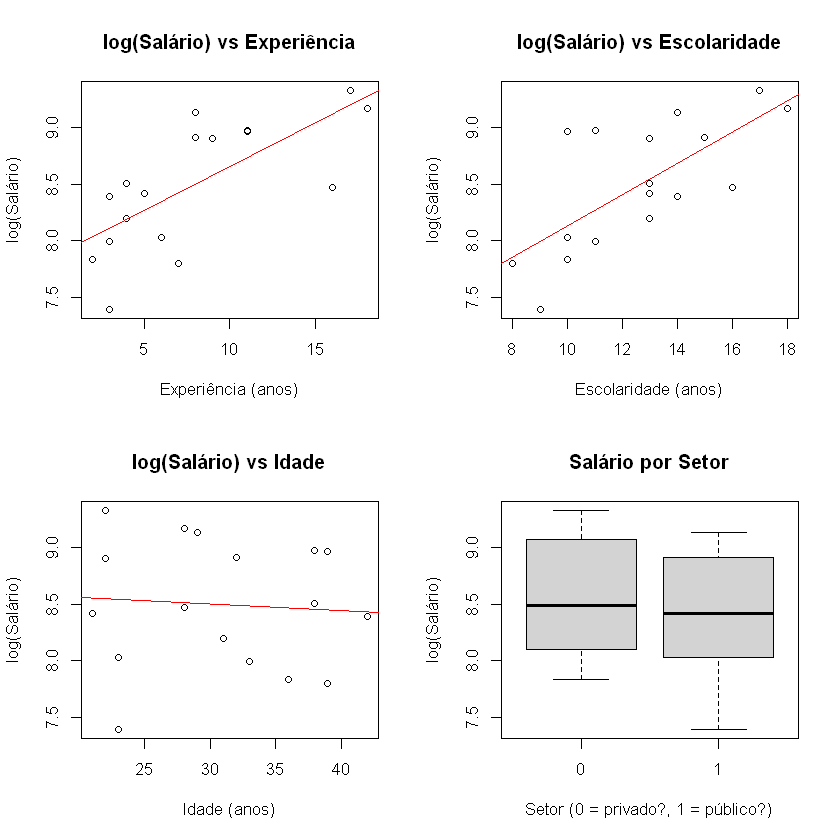

In [4]:
# Configurar janela gráfica
par(mfrow = c(2,2))

# Dispersões
plot(dados$Experiencia, dados$LogSalario,
     xlab = "Experiência (anos)", ylab = "log(Salário)",
     main = "log(Salário) vs Experiência")
abline(lm(LogSalario ~ Experiencia, data = dados), col = "red")

plot(dados$Escolaridade, dados$LogSalario,
     xlab = "Escolaridade (anos)", ylab = "log(Salário)",
     main = "log(Salário) vs Escolaridade")
abline(lm(LogSalario ~ Escolaridade, data = dados), col = "red")

plot(dados$Idade, dados$LogSalario,
     xlab = "Idade (anos)", ylab = "log(Salário)",
     main = "log(Salário) vs Idade")
abline(lm(LogSalario ~ Idade, data = dados), col = "red")

# boxplot do Setor
boxplot(LogSalario ~ Setor, data = dados,
        xlab = "Setor (0 = privado?, 1 = público?)",
        ylab = "log(Salário)",
        main = "Salário por Setor")

---

#### 1.4 Verificando outliers univariados

Pois outliers na resposta ou nas preditoras podem distorcer a análise:

![os boxplots para variaveis quantitativas ](1_4_boxplot.png)

Não parece ter outliers na covariáveis

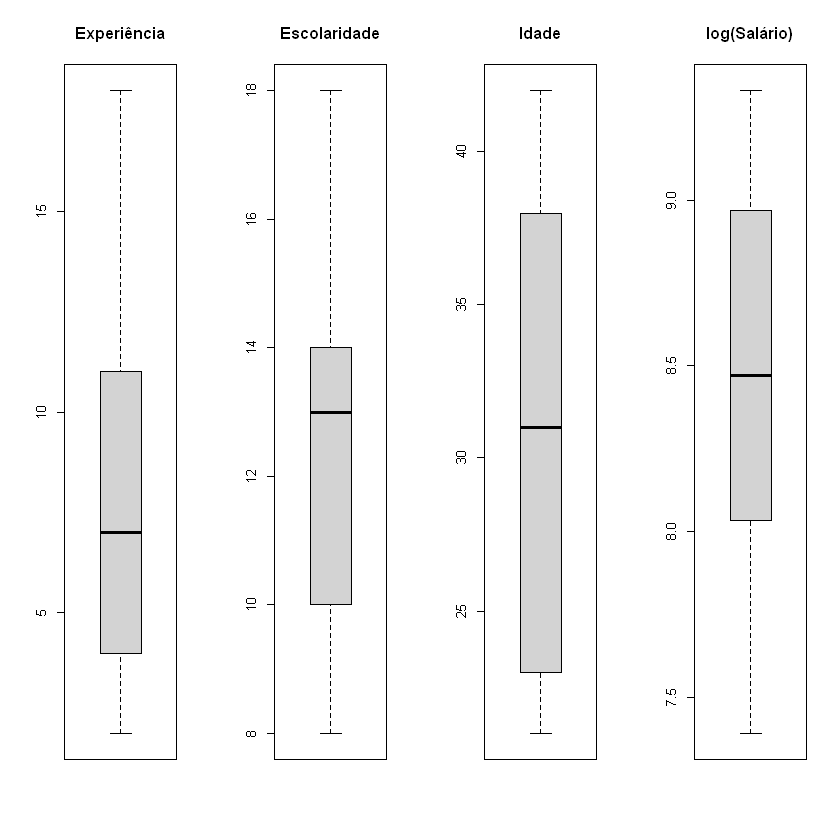

In [5]:
par(mfrow = c(1,4))
boxplot(dados$Experiencia, main = "Experiência")
boxplot(dados$Escolaridade, main = "Escolaridade")
boxplot(dados$Idade, main = "Idade")
boxplot(dados$LogSal, main = "log(Salário)")

---
#### 1.5 Concluindo etapa 1

* A base de treino tem 17 observações.

* As variáveis estão nos intervalos esperados, sem erros de digitação óbvios.

* A verificação de idade de início de trabalho mostrou valores entre X e Y, a maior parte dos dados é plausível, tem algumas observações pouco inconveniente mas foram mantidas.

* Os gráficos de dispersão sugerem relação aproximadamente linear entre log-salário e as preditoras, exceto talvez a Idade, que apresentou pouco efeito no log-salário. O boxplot de Setor mostra diferença de medianas, indicando possível efeito.

* Nenhum outlier foi detectado nos boxplots; os valores estão dentro do esperado.

---


## Etapa 2:

*Para a base da nossa análise, deve se verificar as seguintes coisas:*

* Redução de dimensão das covariáveis (Parcimonia)
* Matriz de correlação
* Matriz de dispersão
* Multicolinearidade, usando critério de VIF (Variance Inflation Factor) como medida
* Seleção de variáveis

*Qual o ponto dessa etapa? Preparar as covariáveis para o ajuste. *

***Covariáveis IMPORTANTES/RELEVANTES***

| | Experiencia | Escolaridade | Idade | LogSalario |
| :--- | :---: | :---: | :---: | :---: |
| **Experiencia** | 1.000 | 0.636 | -0.250 | 0.711 |
| **Escolaridade** | 0.636 | 1.000 | -0.285 | 0.698 |
| **Idade** | -0.250 | -0.285 | 1.000 | -0.071 |
| **LogSalario** | 0.711 | 0.698 | -0.071 | 1.000 |

![Gráficos de dispersão entre variáveis](2_1_dispersao.png)
![Corrplot das variaveis](2_1_corrplot.png)

A matriz de correlação não revela correlações muito fortes entre as variáveis preditoras (todas as correlações entre pares de preditores são menores que 0,7 em valor absoluto). Isso sugere **ausência de multicolinearidade** problemática, indicando que as covariáveis são aproximadamente linearmente independentes entre si.

---


,Experiencia,Escolaridade,Idade,LogSalario
Experiencia,1.000,0.636,-0.250,0.711
Escolaridade,0.636,1.000,-0.285,0.698
Idade,-0.250,-0.285,1.000,-0.071
LogSalario,0.711,0.698,-0.071,1.000


corrplot 0.92 loaded



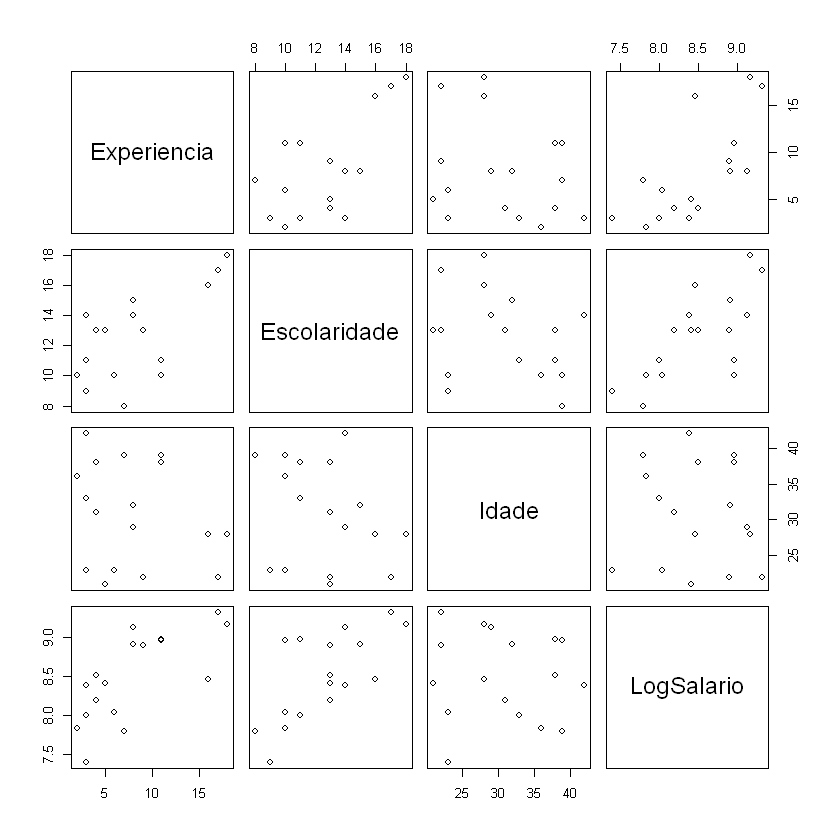

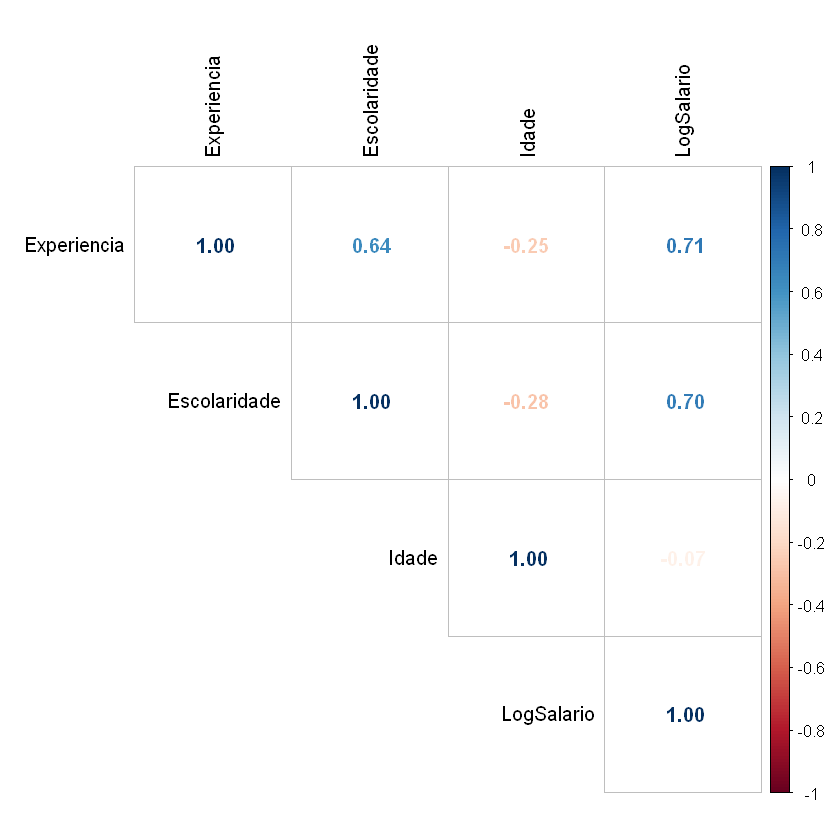

In [6]:
# de pearson
cor_matrix <- cor(dados[, c("Experiencia", "Escolaridade", "Idade", "LogSalario")])
round(cor_matrix, 3)

# visualização:

pairs(dados[, c("Experiencia", "Escolaridade", "Idade", "LogSalario")])
library(corrplot)
corrplot(cor_matrix, method = "number", type = "upper", tl.col = "black")

#### 2.2 Diagnóstico de multicolinearidade usando VIF (Variance Inflation Factor) como medida

| | Experiencia | Escolaridade | Setor | Idade |
| :--- | :---: | :---: | :---: | :---: |
| **VIF** | 1.71 | 1.85 | 1.21 | 1.75 |


Os Valores do Fator de Inflação da Variância (VIF) são todos inferiores a 2. Esse resultado confirma a **ausência de multicolinearidade**; não há evidência de que alguma preditora seja combinação linear das demais.

---

In [7]:
modelo_full <- lm(LogSalario ~ Experiencia + Escolaridade + factor(Setor) + Idade, data = dados)

library(car)

vif(modelo_full)

Carregando pacotes exigidos: carData



Experiencia  Escolaridade factor(Setor)         Idade 
     1.713466      1.853569      1.212649      1.175125

#### 2.3 Seleção de variáveis

* Stepwise: a saída em R fica do jeito abaixo


```text
Call:
lm(formula = LogSalario ~ Experiencia + Escolaridade, data = dados)

Coefficients:
 (Intercept)   Experiencia  Escolaridade  
     7.07122       0.04919       0.08180  
```

O método stepwise both com critério AIC partiu do modelo nulo e 
adicionou/removeu termos até encontrar o modelo com menor AIC. O modelo selecionado contém 
**Escolaridade, Experiencia **. As variável Setor e Idade foram excluídas.

In [8]:
# stepwise backward e forward
# modelo inicial nulo e modelo completo
modelo_nulo <- lm(LogSalario ~ 1, data = dados)
modelo_full  <- lm(LogSalario ~ ., data = dados)  # inclui todas as colunas (Setor como numérica; melhor transformar em fator)

# transformar Setor em fator antes (importante!)
dados$Setor <- factor(dados$Setor)

# reajustar modelo full com Setor fator
modelo_full <- lm(LogSalario ~ ., data = dados)

# stepwise both
step(modelo_nulo, 
     scope = list(lower = modelo_nulo, upper = modelo_full), 
     direction = "both",
     k = 2)   # k=2 para AIC; k=log(n) para BIC

Start:  AIC=-18.54
LogSalario ~ 1

               Df Sum of Sq    RSS     AIC
+ Experiencia   1   2.56599 2.5137 -28.495
+ Escolaridade  1   2.47689 2.6028 -27.903
<none>                      5.0797 -18.535
+ Setor         1   0.06242 5.0173 -16.746
+ Idade         1   0.02566 5.0540 -16.621

Step:  AIC=-28.49
LogSalario ~ Experiencia

               Df Sum of Sq    RSS     AIC
+ Escolaridade  1   0.51781 1.9959 -30.416
<none>                      2.5137 -28.495
+ Idade         1   0.06181 2.4519 -26.918
+ Setor         1   0.03708 2.4766 -26.747
- Experiencia   1   2.56599 5.0797 -18.535

Step:  AIC=-30.42
LogSalario ~ Experiencia + Escolaridade

               Df Sum of Sq    RSS     AIC
<none>                      1.9959 -30.416
+ Idade         1   0.14041 1.8555 -29.656
+ Setor         1   0.12735 1.8685 -29.537
- Escolaridade  1   0.51781 2.5137 -28.495
- Experiencia   1   0.60691 2.6028 -27.903



Call:
lm(formula = LogSalario ~ Experiencia + Escolaridade, data = dados)

Coefficients:
 (Intercept)   Experiencia  Escolaridade  
     7.07122       0.04919       0.08180  


* Cp de Mallows:
```text
Selection Algorithm: exhaustive
         Experiencia Escolaridade Setor1 Idade
1  ( 1 ) "*"         " "          " "    " "  
2  ( 1 ) "*"         "*"          " "    " "  
3  ( 1 ) "*"         "*"          " "    "*"  
4  ( 1 ) "*"         "*"          "*"    "*"  
......
| | 1 variável | 2 variável | 3 variável | 4 variável |
| :--- | :---: | :---: | :---: | :---: |
| **Cp de Mallows** |5.44  | 3.64 |  4.61  | 5.000000 

os Cp de Mallows são:

1 variável: 5.44 (Escolaridade);
***2 variável:  3.64  (Experiencia + Escolaridade);***
3 variável: 4.61  (Experiencia + Escolaridade + Idade);
4 variável: 5.00  (Experiencia + Escolaridade + Idade + Setor)

O modelo com menor Cp é o de 2 variáveis (Experiencia + Escolaridade).

---


Subset selection object
Call: regsubsets.formula(LogSalario ~ ., data = dados, nbest = 1, really.big = F)
4 Variables  (and intercept)
             Forced in Forced out
Experiencia      FALSE      FALSE
Escolaridade     FALSE      FALSE
Setor1           FALSE      FALSE
Idade            FALSE      FALSE
1 subsets of each size up to 4
Selection Algorithm: exhaustive
         Experiencia Escolaridade Setor1 Idade
1  ( 1 ) "*"         " "          " "    " "  
2  ( 1 ) "*"         "*"          " "    " "  
3  ( 1 ) "*"         "*"          " "    "*"  
4  ( 1 ) "*"         "*"          "*"    "*"  

[1] 2

[1] 5.440224 3.641640 4.611587 5.000000


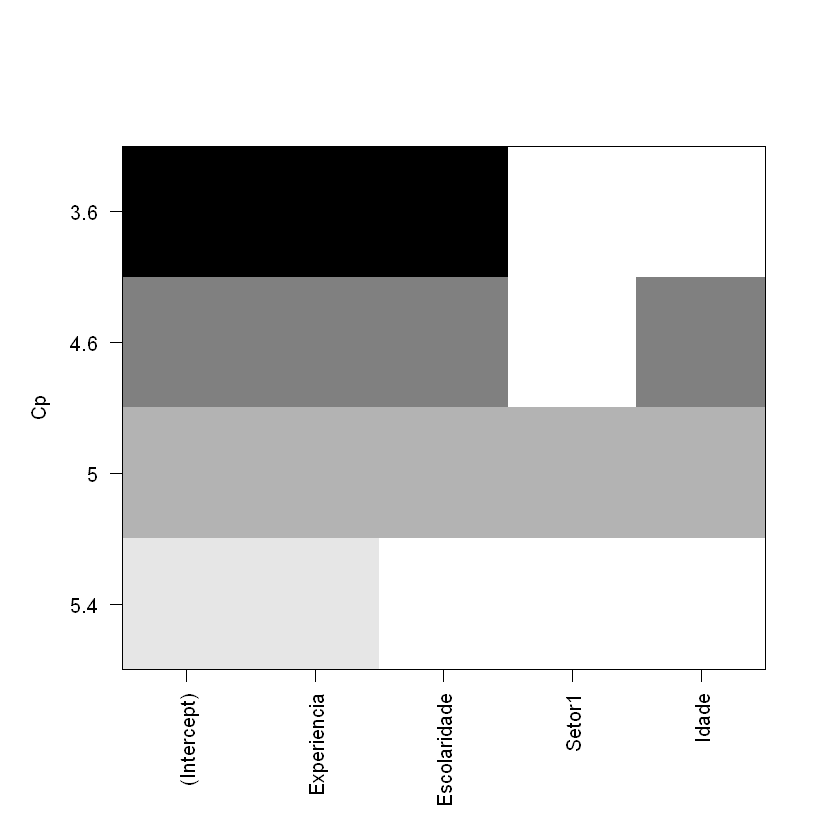

In [9]:
library(leaps)
subsets <- regsubsets(LogSalario ~ ., data = dados, nbest = 1, really.big = F)
summary(subsets)

# Extrair Cp
cp_values <- summary(subsets)$cp
which.min(cp_values)
# Plotar Cp
plot(subsets, scale = "Cp")
print(cp_values)

* LASSO: 

```text
5 x 1 sparse Matrix of class "dgCMatrix"
             lambda.min
(Intercept)  7.40210261
Experiencia  0.03842477
Escolaridade 0.06239494
Setor        .         
Idade        . 
```
O LASSO reteve Experiencia, Escolaridade, e atribui valores baixos de $\lambda$ para Setor e Idade.

---

In [10]:
# LASSO
library(glmnet)
set.seed(20260513)
# preparar matriz de preditores e resposta
x <- model.matrix(LogSalario ~ ., data = dados)[, -1]  # remove intercepto
y <- dados$LogSalario

# ajustar LASSO com validação cruzada para escolher lambda
cv_lasso <- cv.glmnet(x, y, alpha = 1, nfolds = 5)  # ou LOOCV devido ao n pequeno
melhor_lambda <- cv_lasso$lambda.min
melhor_lambda

# Coeficientes do modelo LASSO no lambda ótimo
coef(cv_lasso, s = "lambda.min")

Carregando pacotes exigidos: Matrix



Loaded glmnet 4.1-10



[1] 0.08768766

5 x 1 sparse Matrix of class "dgCMatrix"
             lambda.min
(Intercept)  7.40210261
Experiencia  0.03842477
Escolaridade 0.06239494
Setor1       .         
Idade        .         

#### 2.4 Conclusão da Etapa 2

* A Matriz de Correlação não mostrou correlações elevadas entre preditoras, e os VIFs (todos próximos abaixos de 2) confirmaram ausência de multicolinearidade. 

* Na seleção de variáveis, o método Stepwise com AIC reteve Experiencia, Escolaridade, assim como o Cp de Mallows, e assim como LASSO. 

* Em respeito aos métodos usados (Stepwise, Cp e LASSO), selecionamos para a etapa seguinte **o modelo com Experiencia e Escolaridade**.”

---

## Etapa 3:

1. Ajustar o modelo
2. Fazer Diagnóstico/ análise de resíduo para verificar os pressupostos:
* Lineraridade (gráfico de resíduos vs. valores ajustados)
* Homocedasticidade (o mesmo gráfico + teste de Breusch-Pagan ou outros testes)
* Normalidade dos erros (QQ-plot + teste de Shapiro-Wilk ou outros)
* Independência (gráfico de resíduos vs. ordem de coleta, nesse caso não temos a ordem)

3. Se passar pelo crivo da análise de resíduo --> prossiga
4. Inclua a parte de detecção de outliers e pontos influentes. Opções: $H_{ii}$; DF-Betas; DF-Fits; D-Cook
5. Após análise de resíduo faça testes: F-Global; t; F-Parcial
---

#### 3.1 Ajuste do modelo

Pela etapa 2, o modelo é da forma

$ Y = log(salário) = {\beta}_0 + {\beta}_1*Experiencia  + {\beta}_2*Escolaridade + \varepsilon_{ij} $

```
Call:
lm(formula = LogSalario ~ Experiencia + Escolaridade, data = dados)
... ...
Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   7.07122    0.45630  15.497  3.3e-10 ***
Experiencia   0.04919    0.02384   2.063   0.0581 .  
Escolaridade  0.08180    0.04292   1.906   0.0774 .
... ...
```

* Coeficientes estimados: $\hat{\beta_0} = 7.07$, $\hat{\beta_1} = 0.05$, $\hat{\beta_2} = 0.08$

Interpretação: 

Para cada ano adicional de Experiência, o log-Salário aumenta em média 4%, mantendo a Escolaridade fixa; 

Para cada ano adicional de Escolaridade, o log-salário aumenta em média 8%, mantendo a escolaridade fixa”; 

Não tem interpretação para $\beta_0$ pois aparentemente 0 não está no range das covariáveis Experiência e Escolaridade.

---


In [11]:
modelo <- lm(LogSalario ~ Experiencia + Escolaridade, data = dados)
summary(modelo)


Call:
lm(formula = LogSalario ~ Experiencia + Escolaridade, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.69703 -0.15158  0.02404  0.22629  0.53970 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   7.07122    0.45630  15.497  3.3e-10 ***
Experiencia   0.04919    0.02384   2.063   0.0581 .  
Escolaridade  0.08180    0.04292   1.906   0.0774 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3776 on 14 degrees of freedom
Multiple R-squared:  0.6071,	Adjusted R-squared:  0.551 
F-statistic: 10.82 on 2 and 14 DF,  p-value: 0.001446


#### 3.2 Diagnóstico/ Análise de resíduos
##### 3.2.1 Linearidade

O gráfico de resíduos vs valores ajustados.

![Gráfico de resíduos vs valores ajustados](3_2_1_resid_vs_ajustados.png)

Aparenta ter alguma estrutura de um U invertido, isso pode indicar que um termo quadrático é necessário no modelo (supostamente Experiência^2), mas faço isso se sobrar tempo. Por enquanto vou prosseguir como o mesmo modelo para ver o que acontece.

---

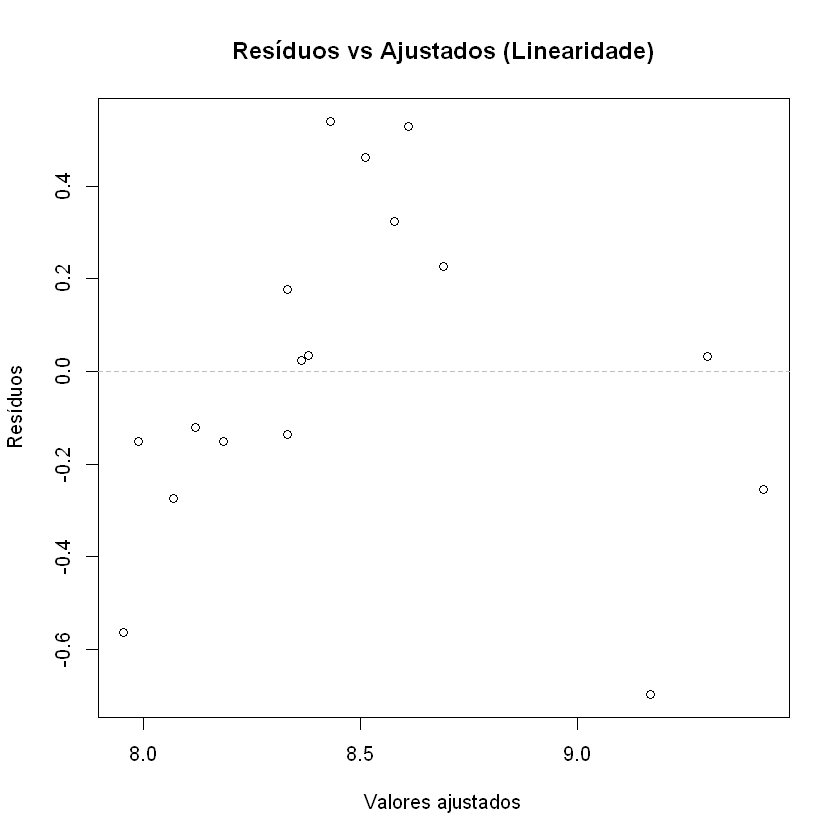

In [12]:
residuos <- residuals(modelo)
ajustados <- fitted(modelo)
residuos_student <- rstudent(modelo)
plot(ajustados, residuos,
     xlab = "Valores ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados (Linearidade)")
abline(h = 0, lty = 2, col = "gray")
# adicionar uma curva suave para ver tendências
lines(0, col = "red")


##### 3.2.2 Homocedasticidade

O gráfico seria o mesmo de antes.

Mas formalmente, pode-se fazer um teste de Breusch-Pagan.

```
	studentized Breusch-Pagan test

data:  modelo
BP = 3.9642, df = 2, p-value = 0.1378
```

Valor-p de 0.1378 não é pequeno, a hipótese da homocedasticidade não é violada, podemos prosseguir.

---

In [13]:
library(lmtest)
bptest(modelo)


Carregando pacotes exigidos: zoo




Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric





	studentized Breusch-Pagan test

data:  modelo
BP = 3.9642, df = 2, p-value = 0.1378


##### 3.2.3 Normalidade dos Erros

QQ-Plot e teste de Shapiro-Wilk:

![QQ-plot dos resíduos](3_2_3_qqplot.png)

```
	Shapiro-Wilk normality test

data:  residuos
W = 0.96178, p-value = 0.6652
```
* No QQ-plot, a maioria dos pontos estão perto da reta. Pequenos desvios nas caudas são toleráveis com n = 21.

* O teste Shapiro-Wilk: $H_0$ = os dados vêm de uma distribuição normal.

Valor-p = 0.66, não rejeita $H_0$ (que afirma os dados são normalmente distribuídos)

(Claro, mesmo se valor-p fosse razoavelmente pequeno, Note que a regressão linear é robusta a desvios de normalidade especialmente para amostras não muito pequenas.)

---


	Shapiro-Wilk normality test

data:  residuos
W = 0.96178, p-value = 0.6652


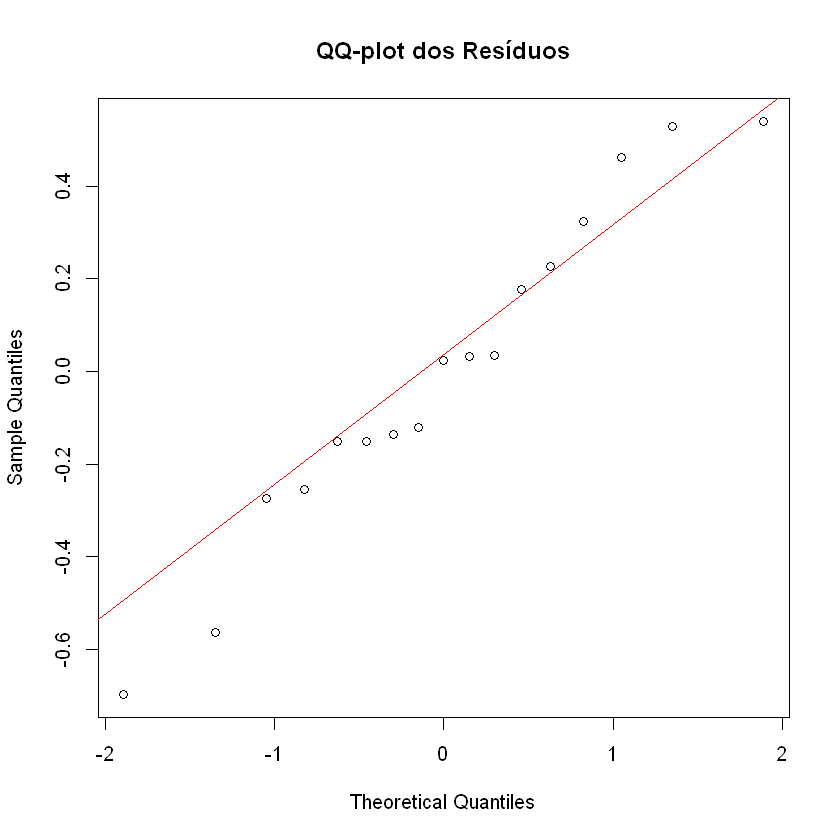

In [14]:
qqnorm(residuos, main = "QQ-plot dos Resíduos")
qqline(residuos, col = "red")

shapiro.test(residuos)

##### 3.2.4 Independência
Como não temos a ordem de coleta, assumimos que são independentes.

---


#### 3.3 Análise de outliers e pontos influentes

##### 3.3.1 Resíduos studentized e alavancagem (os $H_{ii}$)

![Gráfico de residuos studentized.png](3_3_1_residuo_studentized.png)


```
Possíveis outliers (resíduo studentizado > |2|):
   Experiencia Escolaridade Setor Idade LogSalario
11          16           16     0    28       8.47

```

Note que a observação 11 foi classificada como outlier pelo resíduo studentizado.

Possíveis outliers (resíduo studentizado > |2|): 4 
   Experiencia Escolaridade Setor Idade LogSalario
11          16           16     0    28       8.47



	Shapiro-Wilk normality test

data:  rstudent
W = 0.96933, p-value = 0.8066


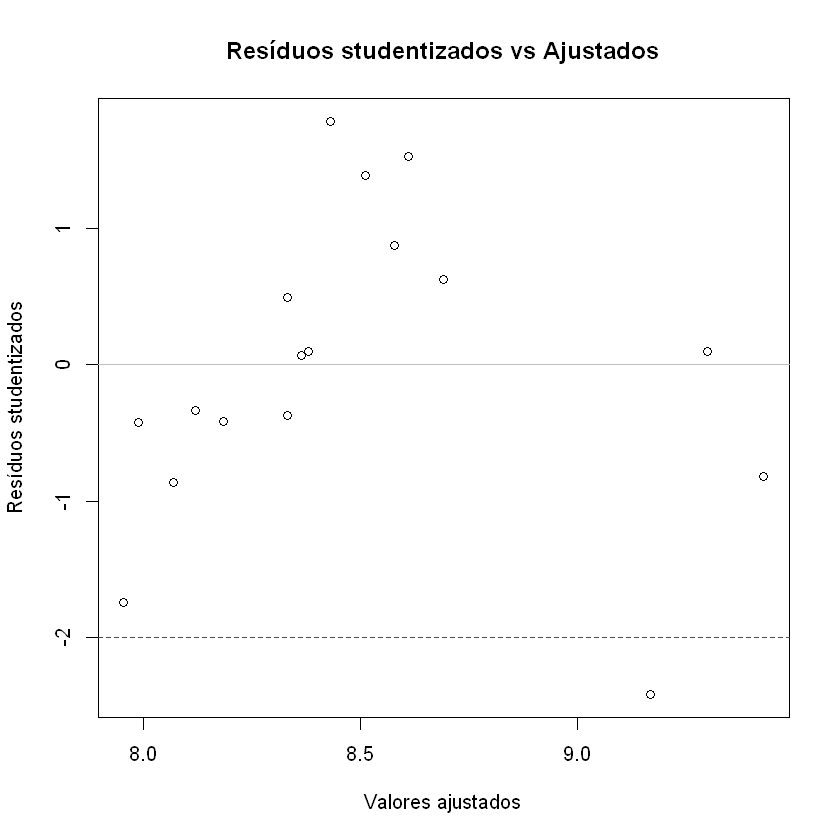

In [15]:
# Adicione após o modelo ajustado (logo após 3.1)
# Resíduos studentizados (jackknife)
rstudent <- rstudent(modelo)

# Gráfico
plot(fitted(modelo), rstudent,
     xlab = "Valores ajustados", ylab = "Resíduos studentizados",
     main = "Resíduos studentizados vs Ajustados")
abline(h = c(-2, 0, 2), lty = c(2,1,2), col = c("red","gray","red"))

# Identificar possíveis outliers (|rstudent| > 2)
outliers <- which(abs(rstudent) > 2)
if(length(outliers) > 0) {
  cat("Possíveis outliers (resíduo studentizado > |2|):", outliers, "\n")
  print(dados[outliers, ])
} else {
  cat("Nenhum outlier grave detectado.\n")
}
# Teste de normalidade (Shapiro-Wilk) sobre rstudent – mais adequado
shapiro.test(rstudent)  # valor-p deve ser > 0.05

Calculuando os valores de alavancagem ($h_{ii}$):
![Os h_ii's ](3_3_1_grafico_de_hii.png)

Não tem valores ($h_ii$) maiores que o limiar = 0.35, ou seja ninguém é considerado de alta alavancagem e merece atenção.

---

21          6         20         11         22          3          9 
0.11694868 0.24082578 0.12911177 0.21643099 0.13505608 0.06149254 0.27098068 
        16          7          2          4         17         23         12 
0.13505608 0.14657272 0.26055828 0.08176314 0.30148229 0.10439557 0.17715739 
        15         10         24 
0.16357865 0.34109536 0.11749400

[1] 0.3529412

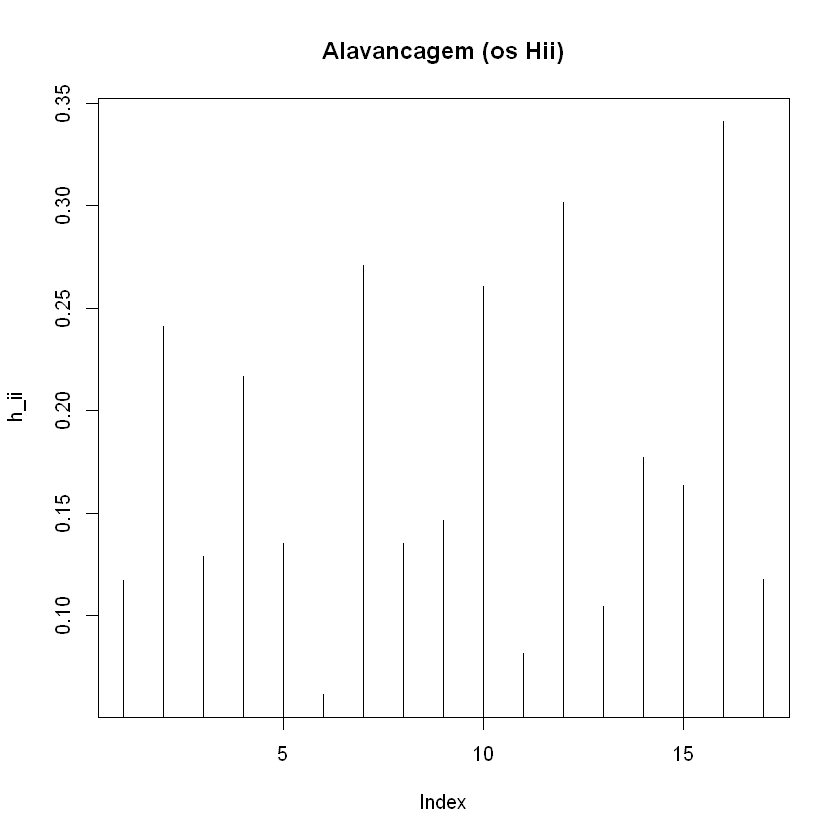

In [16]:
h <- hatvalues(modelo)
limiar_h <- 2 * length(coef(modelo)) / nrow(dados)   # 2p/n
plot(h, type = "h", col = ifelse(h > limiar_h, "red", "black"),
     main = "Alavancagem (os Hii)", ylab = "h_ii")
abline(h = limiar_h, lty = 2, col = "blue")

h
limiar_h

##### 3.3.2 Distância de Cook
![Distância de Cook](3_3_2_DCook.png)

Tem dois valores (observação 4 e 10 do treino) que são maiores que o limiar (4/17 = 0.235 ) sinalizando que são pontos influentes.

---

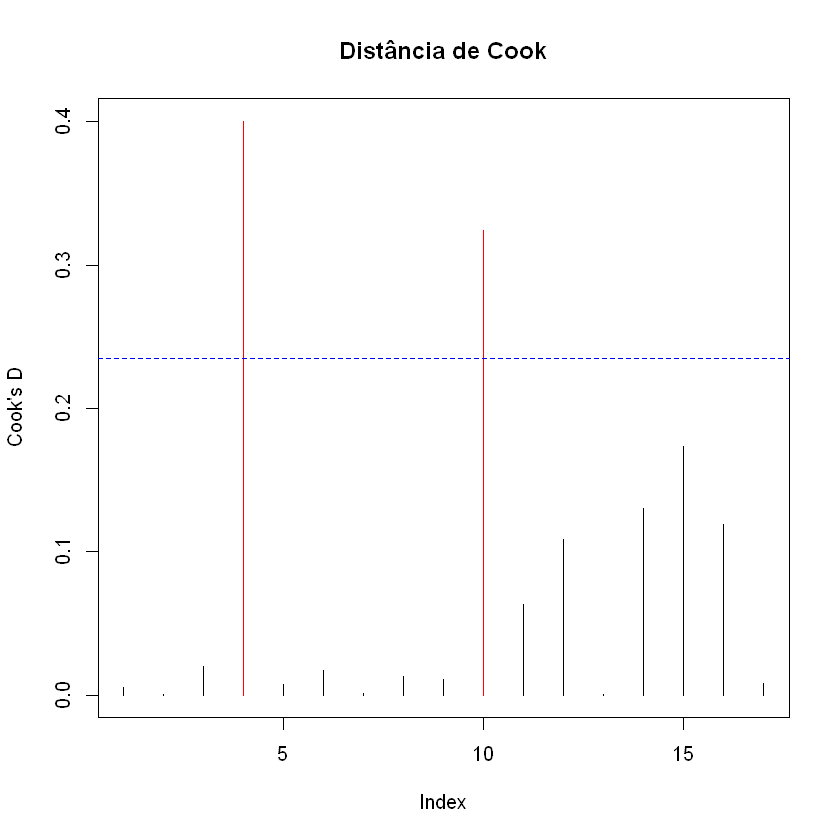

In [17]:
cook <- cooks.distance(modelo)
limiar_cook <- 4 / nrow(dados)   # regra: se maior que 4/n
plot(cook, type = "h", col = ifelse(cook > limiar_cook, "red", "black"),
     main = "Distância de Cook", ylab = "Cook's D")
abline(h = limiar_cook, lty = 2, col = "blue")

#### 3.3.3 DFFITS e DFBETAS
![os DFFits](3_3_3_DFFits.png)

![os DFbetas exp](3_3_3_DEFBETAS_exp.png)

![os DFbetas escolaridade](3_3_3_DEBETAS_escolaridade.png)

As observações 4 e 10 do treino possuem a distância de Cook que ultrapassa o limiar, além disso elas apresentam alta alavancagem/leverage e destacam-se em DFFits e em DFBETAS para Experiencia. Devem ser investigados.

---

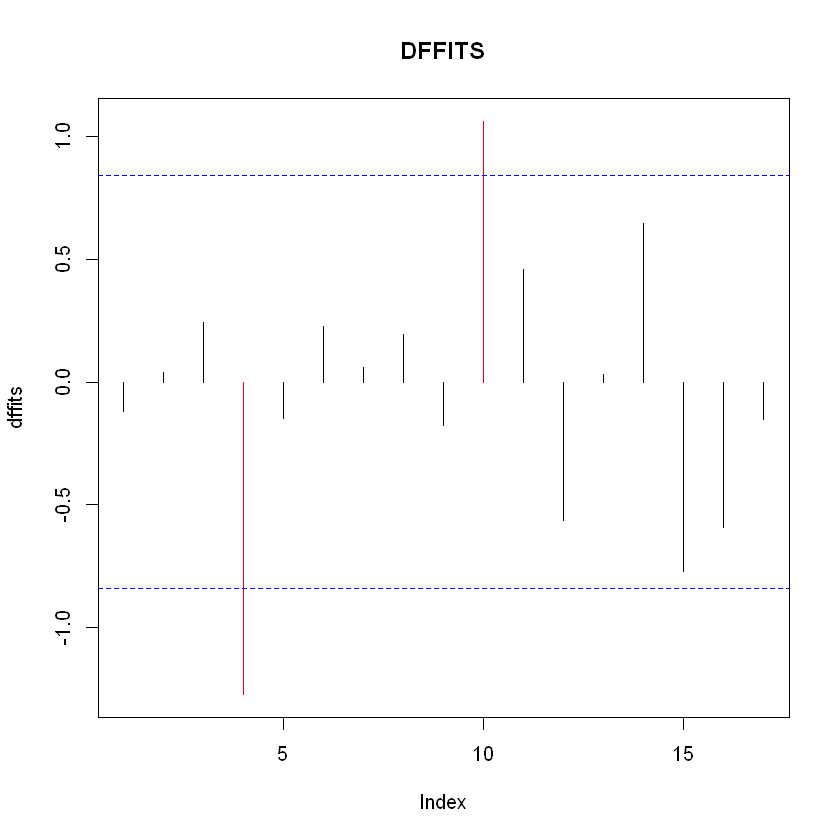

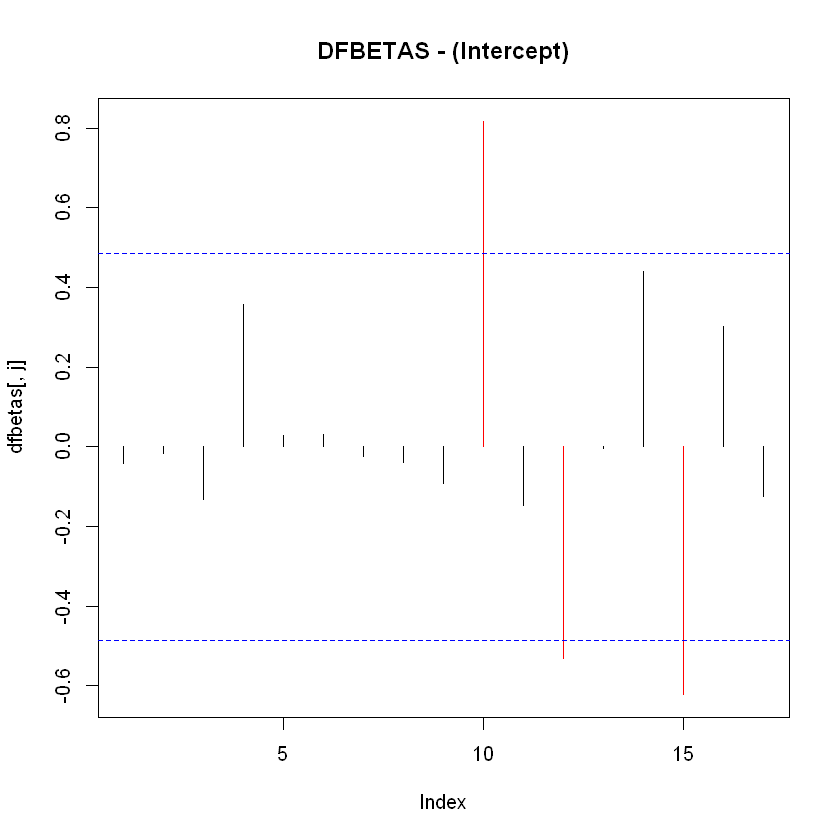

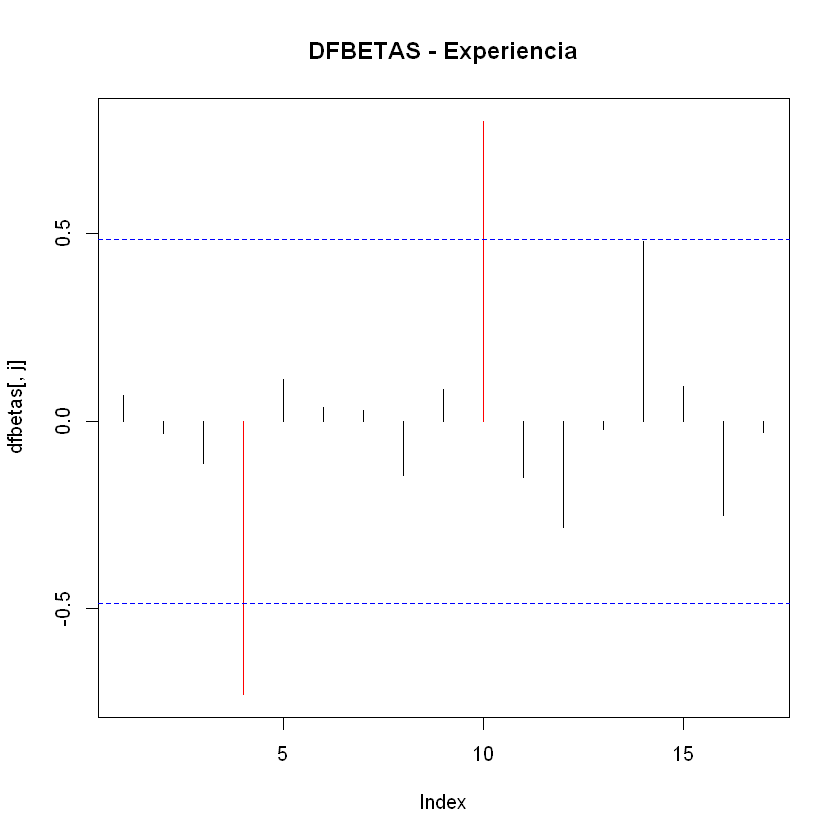

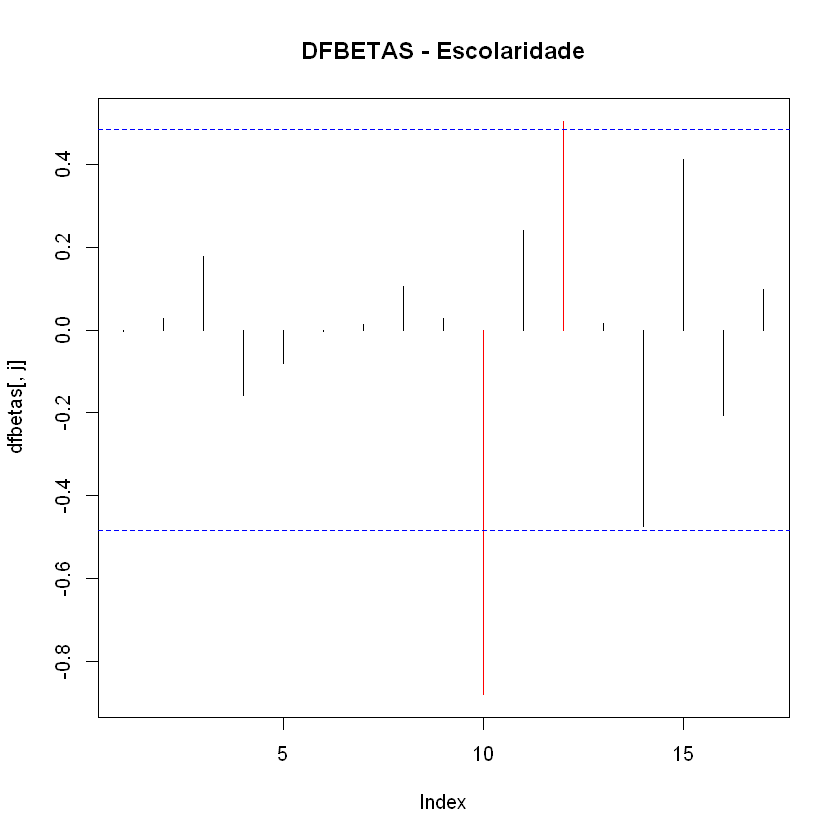

In [18]:
dffits <- dffits(modelo)
limiar_dffits <- 2 * sqrt(length(coef(modelo)) / nrow(dados))
plot(dffits, type = "h", col = ifelse(abs(dffits) > limiar_dffits, "red", "black"),
     main = "DFFITS")
abline(h = c(-limiar_dffits, limiar_dffits), lty = 2, col = "blue")

dfbetas <- dfbetas(modelo)
limiar_dfbetas <- 2 / sqrt(nrow(dados))
# para cada coeficiente (colunas: Intercept, Experiencia, Escolaridade)
for (j in 1:ncol(dfbetas)) {
  plot(dfbetas[, j], type = "h", 
       col = ifelse(abs(dfbetas[, j]) > limiar_dfbetas, "red", "black"),
       main = paste("DFBETAS -", colnames(dfbetas)[j]))
  abline(h = c(-limiar_dfbetas, limiar_dfbetas), lty = 2, col = "blue")
}


#### 3.4 Testes de significância formais

Fazendo um sumário do modelo com comando "summary" do R, tem-se:

```
Call:
lm(formula = LogSalario ~ Experiencia + Escolaridade, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.69703 -0.15158  0.02404  0.22629  0.53970 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   7.07122    0.45630  15.497  3.3e-10 ***
Experiencia   0.04919    0.02384   2.063   0.0581 .  
Escolaridade  0.08180    0.04292   1.906   0.0774 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3776 on 14 degrees of freedom
Multiple R-squared:  0.6071,	Adjusted R-squared:  0.551 
F-statistic: 10.82 on 2 and 14 DF,  p-value: 0.001446
```
Note que o $R^2$ ajustado é 0.551

In [19]:
summary(modelo)


Call:
lm(formula = LogSalario ~ Experiencia + Escolaridade, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.69703 -0.15158  0.02404  0.22629  0.53970 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   7.07122    0.45630  15.497  3.3e-10 ***
Experiencia   0.04919    0.02384   2.063   0.0581 .  
Escolaridade  0.08180    0.04292   1.906   0.0774 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3776 on 14 degrees of freedom
Multiple R-squared:  0.6071,	Adjusted R-squared:  0.551 
F-statistic: 10.82 on 2 and 14 DF,  p-value: 0.001446



Após confirmar que os pressupostos são aceitáveis, realiza-se os testes:

* Teste F global: já obtido no summary. Conclusão: Rejeita H0: $\beta_1$ = $\beta_2$ = 0， valor-p = 0.0014

* Testes t individuais: obtido no summary. Tanto para $\beta_1$ quanto para $\beta_2$,
todos os valores-p não foram inferiores a 0.05 , não rejeita a hipótese de que são nulas.

Teste F parcial: serve para comparar o modelo reduzido com o modelo completo (incluindo Setor e Idade). Isso avalia se as variáveis excluídas são conjuntamente significativas.

Usando **R** e o type III do teste parcial (comando é Anova(modelo, type = "III")), a saída fica: 

```
A anova: 4 × 4
Sum Sq	Df	F value	Pr(>F)
<dbl>	<dbl>	<dbl>	<dbl>
(Intercept)	34.2369378	1	240.151437	3.304527e-10
Experiencia	0.6069104	1	4.257110	5.814262e-02
Escolaridade	0.5178092	1	3.632119	7.741689e-02
Residuals	1.9958953	14	NA	NA

```
Assim, pode-se dizer que:

* Para Experiência: valor-p = 0.058 não é muito pequeno, isso significa que remover “Experiência” piora (moderadamente) o ajuste do modelo, mesmo mantendo “Escolaridade”.

* Para Escolaridade: valor-p = 0.074 não é muito pequeno, isso significa que remover Escolaridade piora (moderadamente) o ajuste do modelo, mesmo mantendo "Experiência".

Resumindo: tanto experiência quanto escolaridade apresentaram contribuição mais ou menos significativa para explicar a variável resposta LogSalário.

E fazendo anova comparando o modelo reduzido e o modelo full, tem-se um valor-p = 0.30, confirmando que a exclusão de Setor e Idade não compromete o ajuste.

---

In [20]:
library(car)
Anova(modelo, type = "III")
modelo_full_test <- lm(LogSalario ~ Experiencia + Escolaridade + Setor + Idade, data = dados)
anova(modelo, modelo_full_test)

,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),34.2369378,1,240.151437,3.304527e-10
Experiencia,0.6069104,1,4.257110,5.814262e-02
Escolaridade,0.5178092,1,3.632119,7.741689e-02
Residuals,1.9958953,14,NA,NA


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,14,1.995895,NA,NA,NA,NA
2,12,1.635797,2,0.3600988,1.32082,0.3030743


#### 3.5 Conclusão da Etapa3 

O diagnóstico de resíduos não revelou violações muito graves dos pressupostos:

* A linearidade não parece fortemente adequada, talvez precise de um termo quadrático

* A hmocedasticidade é garantida (teste de Breusch-Pagan valor-p = 0.13),

* A normalidade dos resíduos é sustentável (Shapiro-Wilk p = 0.66) 

* Não há indícios de dependência. 

É detectado um possível outlier (obs. 11) pelos resíduo studentizado.

A análise de influência detectou pontos com leverage ligeiramente alto (obs. 4 e 10), e a Distância de Cook dessa duas observações são maiores que o limiar. 

Os testes de significância indicam que o modelo como um todo não é muito significativo (coeficiente de Determinação ajustado $R^2$ = 0.551) (F-global valor-p = 0.001) e que ambos os preditores (Experiência e Escolaridade) são moderadamente relevantes (os valores-p pequenos). 

O teste F-parcial (type III) retornou valores-p são pequenos, ou seja as covariáveis Experiência e Escolaridade são moderadamente significativos.

E fazendo anova comparando o modelo reduzido e o modelo full, tem-se um valor-p = 0.30, confirmando que a exclusão de Setor e Idade não compromete o ajuste. 

Portanto, o modelo reduzido não parece muito apropriado, mas isso vai ser investigado na etapa 4.

---

## Etapa 4:
**Validação** 

Procurar a resposta da seguinte questão: **O modelo é útil para uma nova Base de dados??**

O que pode ser feito é antes de ajustar o modelo, separar um conjunto pequeno para validar depois.

1. Divisão aleatória antes de ajustar. exemplo: 70% treino e 30% teste.
2. Opções de validar o modelo:
* Reportar medidas preditivas como RMSE
* Validação cruzada (k-fold)

**Note que n = 24 - 7 = 17, a amostra é pequena**

---

#### 4.1 Divisão em treino e teste

O modelo foi ajustado com as 17 observações separadas, pois já no início com o set.seed(20260513) para reprodutividade, o grupo teste é formado por 7 observações (1;5;8;13;14;18;19), e o grupo treino é o que sobrou.

#### 4.2 Predição no conjunto de teste.

|  Indice     | Experiencia | Escolaridade | Setor | Idade | LogSalario | Pred_LogSal |
|---------|--------------|---------------|--------|--------|-------------|--------------|
| |
|1 | 5  | 16 | 1 | 38 | 8.874 | 8.625 |
|5 | 3  | 8  | 1 | 23 | 7.472 | 7.873 |
|8 | 11 | 9  | 0 | 28 | 8.599 | 8.348 |
|13 | 3  | 15 | 0 | 42 | 8.632 | 8.445 |
|14 | 3  | 12  | 0 | 32 | 8.149 | 8.200 |
|18 | 6  | 11 | 0 | 34 | 9.060 | 8.75 |
|19 | 4  | 11   | 1  |  39   |  8.156    | 8.167 |

In [21]:
predicoes <- predict(modelo, newdata = dados_teste)
dados_teste$Pred_LogSal <- predicoes
predicoes
dados_teste

1        5        8       13       14       18       19 
8.625937 7.873175 8.348498 8.445758 8.200365 8.756926 8.167758

,Experiencia,Escolaridade,Setor,Idade,LogSalario,Pred_LogSal
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,5,16,1,38,8.874,8.625937
5,3,8,1,23,7.472,7.873175
8,11,9,0,28,8.599,8.348498
13,3,15,0,42,8.632,8.445758
14,3,12,0,32,8.149,8.200365
18,6,17,0,34,9.060,8.756926
19,4,11,1,39,8.156,8.167758


##### 4.3 Métricas de erro de predição

São usadas as seugintes métricas: 

* RMSE (raiz do erro quadrático médio)
* MAE (erro absoluto médio)
* $R^2$ (Coeficiente de determinação preditivo)

```
RMSE_teste: 0.2434 
MAE_teste: 0.2075 
R² preditivo: 0.9676 

RMSE_treino: 0.3426 
MAE_treino: 0.2763 

```

--- 

#### 4.4 O que dizer sobre essas métricas

Para avaliar a capacidade preditiva do modelo, a base (24 obs.) é dividida aleatoriamente em treino (17 obs.) e teste (7 obs.), com semente 20260512. 

É feito um ajuste do modelo no treino e obtivemos no teste um $RMSE_{teste}$ de 0.2434, $MAE_{teste}$ de 0.2075  e R² preditivo de 0.9676, enquanto $RMSE_{treino}$ é 0.3426 e $MAE_{treino}$ é 0.2763. 

Apesar do tamanho diminuto do conjunto de teste, o resultado acima obtido por divisão treino-teste sugere que o modelo é moderadamente útil para novas observações.

---

In [22]:
# erros
erro_teste <- dados_teste$LogSalario - dados_teste$Pred_LogSal

# RMSE
RMSE_teste <- sqrt(mean(erro_teste^2))

# MAE
mae_teste <- mean(abs(erro_teste))

# R² preditivo (correlação ao quadrado)
r2_pred <- cor(dados_teste$LogSalario, dados_teste$Pred_LogSal)^2

# Exibir resultados
cat("RMSE_teste:", round(RMSE_teste, 4), "\n",
    "MAE_teste:", round(mae_teste, 4), "\n",
    "R² preditivo:", round(r2_pred, 4), "\n")

RMSE_teste: 0.2434 
 MAE_teste: 0.2075 
 R² preditivo: 0.9676 


In [23]:
predicoes_treino <- predict(modelo, newdata = dados)
dados$Pred_LogSal <- predicoes_treino
# erros
erro_treino <- dados$LogSalario - dados$Pred_LogSal

# RMSE
rmse_treino <- sqrt(mean(erro_treino^2))

# MAE
mae_treino <- mean(abs(erro_treino))

# Exibir resultados
cat("RMSE_treino:", round(rmse_treino, 4), "\n",
    "MAE_treino:", round(mae_treino, 4), "\n")

RMSE_treino: 0.3426 
 MAE_treino: 0.2763 


#### 4.5 Conclusão da Validação Cruzada (5‑fold)

A validação cruzada com 5 partições foi aplicada ao modelo `LogSalario ~ Experiencia + Escolaridade` utilizando **todos os 24 dados brutos** (sem separação prévia treino/teste). Os resultados médios foram:

- **RMSE = 0,3629**  
- **R² = 0,7317**  
- **MAE = 0,2950**

**Comparação com as métricas anteriores (hold‑out):**  

| Métrica | Hold‑out (treino) | Hold‑out (teste) | Validação Cruzada (5‑fold) |
|---------|------------------|------------------|----------------------------|
| RMSE    | 0,3426           | 0,2434           | **0,3629**                 |
| R²      | 0,6071 (ajust=0,551) | 0,9676 (preditivo) | **0,7317**                 |
| MAE     | 0,2763           | 0,2075           | **0,2950**                 |

**Interpretação:**

1. **O RMSE da validação cruzada (0,3629) é ligeiramente superior ao RMSE de treino (0,3426)**, o que era esperado – a CV avalia o erro em dados não vistos durante o treinamento de cada fold.  
   - Porém, o RMSE da CV é **maior do que o RMSE obtido no conjunto de teste hold‑out (0,2434)**. Isso indica que a estimativa pontual baseada em uma única divisão treino‑teste (com apenas 7 observações) foi **otimista** (subestimou o erro real). A CV fornece uma métrica mais estável e confiável para uma amostra pequena (n=24).

2. **O R² médio da CV (0,7317)** é **muito menor do que o R² preditivo do hold‑out (0,9676)**, confirmando que o hold‑out superestimou a capacidade preditiva devido ao tamanho reduzido do conjunto de teste.  
   - O valor 0,7317 está mais próximo do R² ajustado do treino (0,551) e do R² múltiplo (0,6071), sugerindo que o modelo explica cerca de **73% da variabilidade de novos dados**, em média.

3. **O MAE da CV (0,2950)** indica que, em média, a previsão do log‑salário erra por aproximadamente **0,30 unidades**. Na escala original do salário (exponencial), isso representa um erro multiplicativo de cerca de `exp(0,295) ≈ 1,34` (34% de erro percentual médio) – um valor moderado, mas que pode ser aprimorado.

**Conclusão final sobre a utilidade do modelo:**

- O modelo com **Experiência e Escolaridade** apresenta **capacidade preditiva razoável**, porém não excelente.  
- A validação cruzada corrige o viés otimista do hold‑out e mostra que o erro esperado em novas observações é **RMSE ≈ 0,36**, ainda assim inferior ao desvio padrão da resposta (`sd(dados_brutos$LogSalario) ≈ 0,54`), indicando que o modelo agrega valor em relação a uma previsão ingênua (apenas a média).  
- Recomenda‑se, em trabalhos futuros, testar a inclusão de termos quadráticos (especialmente para `Experiencia`) ou investigar a interação entre escolaridade e setor, pois o R² da CV de 0,73 deixa margem para melhoria.

**Portanto, o modelo é útil, mas deve ser usado com cautela – especialmente porque a amostra é pequena (24 observações) e os pontos influentes (obs. 4 e 10) podem distorcer as estimativas em novas bases.**


In [25]:
# 4.5 Validação Cruzada (5-fold) no modelo com Experiencia + Escolaridade
set.seed(20260513)
library(caret)
train_control <- trainControl(method = "cv", number = 5)
cv_model <- train(LogSalario ~ Experiencia + Escolaridade, 
                  data = dados_brutos,  # use os dados brutos originais (24 obs.)
                  method = "lm",
                  trControl = train_control)
print(cv_model)
# Extraia o RMSE médio da CV
rmse_cv <- cv_model$results$RMSE
cat("RMSE médio (5-fold CV):", round(rmse_cv, 4), "\n")

ERROR: Error: package or namespace load failed for 'caret' in inDL(x, as.logical(local), as.logical(now), ...):
 impossível carregar objeto compartilhado 'C:/Users/Marcelo/miniconda3/envs/rdev/lib/R/library/ModelMetrics/libs/x64/ModelMetrics.dll':
  LoadLibrary failure:  Não foi possível encontrar o procedimento especificado.



### Adicional:

# Problema no Teste de linearidade: 
incluir quadrático de Experiencia -----> LogSalario ~ Experiencia + I(Experiencia^2) + Escolaridade

```
RMSE_teste: 0.117 
MAE_teste: 0.0993 
R² preditivo: 0.9586
```
![residuo do modelo com termo quadratico.png](Adicional_model_residuo.png)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,14,1.995895,NA,NA,NA,NA
2,13,1.087741,1,0.9081546,10.8537,0.005808919


1        5        8       13       14       18       19 
8.884548 7.527247 8.436988 8.424800 8.040134 9.144497 8.089021

,Experiencia,Escolaridade,Setor,Idade,LogSalario,Pred_LogSal
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,5,16,1,38,8.874,8.884548
5,3,8,1,23,7.472,7.527247
8,11,9,0,28,8.599,8.436988
13,3,15,0,42,8.632,8.424800
14,3,12,0,32,8.149,8.040134
18,6,17,0,34,9.060,9.144497
19,4,11,1,39,8.156,8.089021


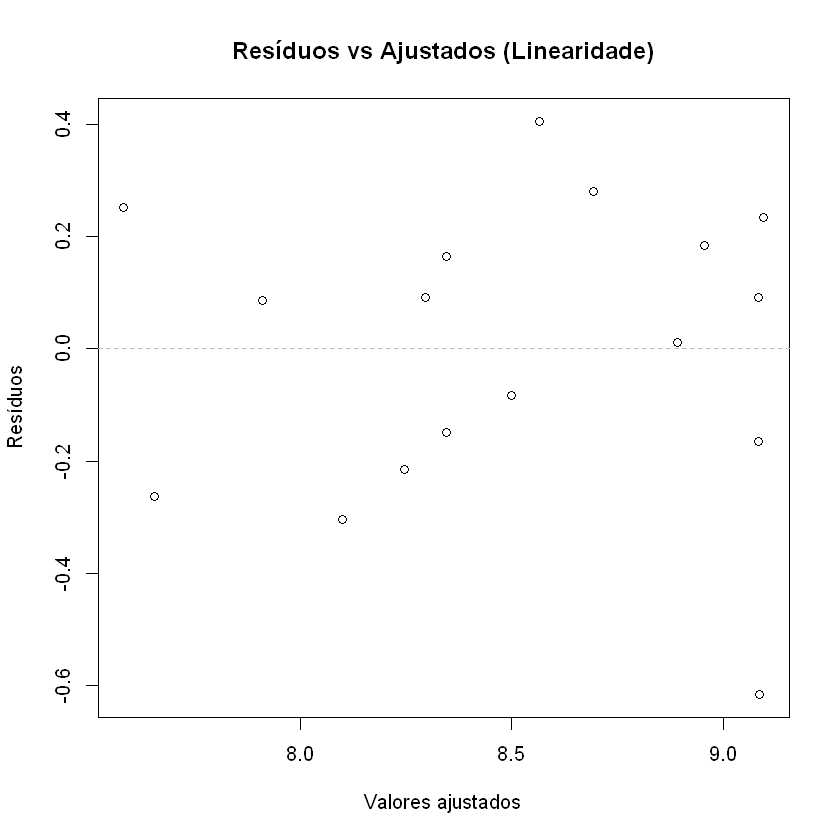

In [ ]:
# Teste de linearidade: incluir quadrático de Experiencia
modelo_quad <- lm(LogSalario ~ Experiencia + I(Experiencia^2) + Escolaridade, data = dados)
anova(modelo, modelo_quad)  # p-value > 0.05? Se < 0.05, quadrático melhora.
# Se necessário, mostre o gráfico de resíduos do modelo_quad.

predicoes <- predict(modelo_quad, newdata = dados_teste)
dados_teste$Pred_LogSal <- predicoes
predicoes
dados_teste
residuos <- residuals(modelo_quad)
ajustados <- fitted(modelo_quad)
residuos_student <- rstudent(modelo_quad)
plot(ajustados, residuos,
     xlab = "Valores ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados")
abline(h = 0, lty = 2, col = "gray")
# adicionar uma curva suave para ver tendências
lines(0, col = "red")

In [31]:
# erros
erro_teste <- dados_teste$LogSalario - dados_teste$Pred_LogSal

# RMSE
RMSE_teste <- sqrt(mean(erro_teste^2))

# MAE
mae_teste <- mean(abs(erro_teste))

# R² preditivo (correlação ao quadrado)
r2_pred <- cor(dados_teste$LogSalario, dados_teste$Pred_LogSal)^2

# Exibir resultados
cat("RMSE_teste:", round(RMSE_teste, 4), "\n",
    "MAE_teste:", round(mae_teste, 4), "\n",
    "R² preditivo:", round(r2_pred, 4), "\n")

    predicoes_treino <- predict(modelo, newdata = dados)
dados$Pred_LogSal <- predicoes_treino
# erros
erro_treino <- dados$LogSalario - dados$Pred_LogSal

# RMSE
rmse_treino <- sqrt(mean(erro_treino^2))

# MAE
mae_treino <- mean(abs(erro_treino))

# Exibir resultados
cat("RMSE_treino:", round(rmse_treino, 4), "\n",
    "MAE_treino:", round(mae_treino, 4), "\n")

RMSE_teste: 0.117 
 MAE_teste: 0.0993 
 R² preditivo: 0.9586 
RMSE_treino: 0.3426 
 MAE_treino: 0.2763 
